<a href="https://colab.research.google.com/github/armakoua-a11y/colab-git-Project1_StockMarketEDA-AK/blob/main/Project1_StockMarketEDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Project 1: Data Collection and Initial Analysis of Stock Market Data

Dataset: Daily Historical Stock Prices (1970–2018) — historical_stocks.csv & historical_stock_prices.csv


# 1. Data Collection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

stocks = pd.read_csv('historical_stocks.csv')
prices = pd.read_csv('historical_stock_prices.csv')

print("historical_stocks.csv:", stocks.shape)
print("historical_stock_prices.csv:", prices.shape)


historical_stocks.csv: (6460, 5)
historical_stock_prices.csv: (4084890, 8)


In [4]:
print(stocks.head())

  ticker exchange                                    name             sector  \
0    PIH   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
1  PIHPP   NASDAQ  1347 PROPERTY INSURANCE HOLDINGS, INC.            FINANCE   
2   TURN   NASDAQ                180 DEGREE CAPITAL CORP.            FINANCE   
3   FLWS   NASDAQ                 1-800 FLOWERS.COM, INC.  CONSUMER SERVICES   
4   FCCY   NASDAQ           1ST CONSTITUTION BANCORP (NJ)            FINANCE   

                     industry  
0  PROPERTY-CASUALTY INSURERS  
1  PROPERTY-CASUALTY INSURERS  
2  FINANCE/INVESTORS SERVICES  
3      OTHER SPECIALTY STORES  
4        SAVINGS INSTITUTIONS  


In [5]:
print(prices.head())

  ticker   open  close  adj_close    low   high     volume        date
0    AHH  11.50  11.58   8.493155  11.25  11.68  4633900.0  2013-05-08
1    AHH  11.66  11.55   8.471151  11.50  11.66   275800.0  2013-05-09
2    AHH  11.55  11.60   8.507822  11.50  11.60   277100.0  2013-05-10
3    AHH  11.63  11.65   8.544494  11.55  11.65   147400.0  2013-05-13
4    AHH  11.60  11.53   8.456484  11.50  11.60   184100.0  2013-05-14


In [6]:
print("=== historical_stocks.csv dtypes ===")
print(stocks.dtypes)

print("=== historical_stock_prices.csv dtypes ===")
print(prices.dtypes)


=== historical_stocks.csv dtypes ===
ticker      object
exchange    object
name        object
sector      object
industry    object
dtype: object
=== historical_stock_prices.csv dtypes ===
ticker        object
open         float64
close        float64
adj_close    float64
low          float64
high         float64
volume       float64
date          object
dtype: object


In [7]:
stocks.info()
prices.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4084890 entries, 0 to 4084889
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     object 
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     float64
 7   date       object 
dtypes: float64(6), object(2)
memory usage: 249.3+ MB


# 2. Data Cleaning

In [8]:
# Missing values
print("Missing values per column (prices):")
print(prices.isnull().sum())

print("Missing values per column (stocks):")
print(stocks.isnull().sum())


Missing values per column (prices):
ticker       0
open         0
close        1
adj_close    1
low          1
high         1
volume       1
date         1
dtype: int64
Missing values per column (stocks):
ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64


In [9]:
# Fill missing values
prices.fillna(prices.median(numeric_only=True), inplace=True)


In [10]:
# Duplicate entries
n_dupes = prices.duplicated().sum()
print(f"Duplicate rows found: {n_dupes}")

prices = prices.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {prices.shape}")


Duplicate rows found: 0
Shape after removing duplicates: (4084890, 8)


In [11]:
# Convert 'date' to datetime and set as index
prices['date'] = pd.to_datetime(prices['date'])
prices = prices.set_index('date').sort_index()

print(prices.head())


           ticker       open      close  adj_close        low       high  \
date                                                                       
1970-01-02    MRO   5.633611   5.757882   0.203525   5.633611   5.757882   
1970-01-02    CNP  11.099500  11.169750   0.107916  10.994125  11.204875   
1970-01-02    MMM   6.851562   6.851562   0.438697   6.843750   6.890625   
1970-01-02    MRK   1.565972   1.545139   0.268152   1.541667   1.565972   
1970-01-05    CNP  11.169750  11.345375   0.109612  11.169750  11.345375   

              volume  
date                  
1970-01-02  105900.0  
1970-01-02   24400.0  
1970-01-02   72000.0  
1970-01-02  475200.0  
1970-01-05   13700.0  


# 3. Data Segmentation by Decade
Add a decade column and split into one DataFrame per decade.


In [12]:
def get_decade(year):
    return f"{(year // 10) * 10}s"

prices_filtered = prices[prices.index.notna()].copy()

prices_filtered['decade'] = prices_filtered.index.year.map(get_decade)

decade_order = sorted(prices_filtered['decade'].unique(), key=lambda d: int(d[:-1]))
print("Decades present:", decade_order)

decade_dfs = {d: prices_filtered[prices_filtered['decade'] == d].copy() for d in decade_order}
for d, df in decade_dfs.items():
    print(f"{d}: {df.shape[0]:,} rows, {df.index.min().date()} to {df.index.max().date()}")

Decades present: ['1970s', '1980s', '1990s', '2000s', '2010s']
1970s: 23,873 rows, 1970-01-02 to 1979-12-31
1980s: 271,181 rows, 1980-01-02 to 1989-12-29
1990s: 647,303 rows, 1990-01-02 to 1999-12-31
2000s: 1,301,396 rows, 2000-01-03 to 2009-12-31
2010s: 1,841,136 rows, 2010-01-04 to 2018-08-24


# 4. Exploratory Data Analysis by Decade

4.1 Merge with sector/industry


In [13]:
prices_full = prices.reset_index().merge(stocks, on='ticker', how='left')
prices_full = prices_full.set_index('date').sort_index()
print(prices_full.head())


           ticker       open      close  adj_close        low       high  \
date                                                                       
1970-01-02    MRO   5.633611   5.757882   0.203525   5.633611   5.757882   
1970-01-02    CNP  11.099500  11.169750   0.107916  10.994125  11.204875   
1970-01-02    MMM   6.851562   6.851562   0.438697   6.843750   6.890625   
1970-01-02    MRK   1.565972   1.545139   0.268152   1.541667   1.565972   
1970-01-05    CNP  11.169750  11.345375   0.109612  11.169750  11.345375   

              volume exchange                      name            sector  \
date                                                                        
1970-01-02  105900.0     NYSE  MARATHON OIL CORPORATION            ENERGY   
1970-01-02   24400.0     NYSE  CENTERPOINT ENERGY, INC.  PUBLIC UTILITIES   
1970-01-02   72000.0     NYSE                3M COMPANY       HEALTH CARE   
1970-01-02  475200.0     NYSE     MERCK & COMPANY, INC.       HEALTH CARE   
1970-

In [14]:
print("Any tickers without a sector match?", prices_full['sector'].isnull().sum(), "rows")
print(prices_full['sector'].value_counts())


Any tickers without a sector match? 418563 rows
sector
FINANCE                  727159
TECHNOLOGY               542203
HEALTH CARE              465651
CONSUMER SERVICES        457116
CAPITAL GOODS            324017
BASIC INDUSTRIES         258724
ENERGY                   194702
PUBLIC UTILITIES         171310
CONSUMER DURABLES        166265
CONSUMER NON-DURABLES    163038
MISCELLANEOUS            103711
TRANSPORTATION            92431
Name: count, dtype: int64


### 4.2 Summary statistics by decade

In [16]:
summary_cols = ['open', 'high', 'low', 'close', 'volume']
decade_summaries = {}

prices_full = prices_full[prices_full.index.notna()].copy()

# Add the 'decade' column to prices_full
prices_full['decade'] = prices_full.index.year.map(get_decade)

for d in decade_order:
    df = prices_full[prices_full['decade'] == d]
    stats = df[summary_cols].agg(['mean', 'median', 'std']).T
    decade_summaries[d] = stats
    print(f"--- {d} ---")
    print(stats.round(2))


--- 1970s ---
             mean     median         std
open         5.32       5.00        4.26
high         5.37       5.03        4.29
low          5.27       4.95        4.23
close        5.32       4.99        4.26
volume  548222.65  140400.00  1058353.41
--- 1980s ---
             mean    median         std
open        29.36      5.00     1325.63
high        29.97      5.06     1348.24
low         28.78      4.94     1300.60
close       29.42      5.00     1330.26
volume  849262.41  49000.00  5275873.38
--- 1990s ---
             mean    median         std
open        44.14      9.73     1367.70
high        45.46      9.88     1421.49
low         42.79      9.56     1318.20
close       44.09      9.74     1369.34
volume  915775.42  53900.00  7221668.38
--- 2000s ---
              mean     median          std
open        314.05      15.66      8735.49
high        321.25      15.95      8934.40
low         307.10      15.38      8572.98
close       314.37      15.66      8771.22
vol

In [17]:
# Combine into a single comparison table (index: decade, field | columns: mean, median, std)
combined = pd.concat(decade_summaries, names=['decade', 'field'])
print(combined.round(2))


                     mean     median          std
decade field                                     
1970s  open          5.32       5.00         4.26
       high          5.37       5.03         4.29
       low           5.27       4.95         4.23
       close         5.32       4.99         4.26
       volume   548222.65  140400.00   1058353.41
1980s  open         29.36       5.00      1325.63
       high         29.97       5.06      1348.24
       low          28.78       4.94      1300.60
       close        29.42       5.00      1330.26
       volume   849262.41   49000.00   5275873.38
1990s  open         44.14       9.73      1367.70
       high         45.46       9.88      1421.49
       low          42.79       9.56      1318.20
       close        44.09       9.74      1369.34
       volume   915775.42   53900.00   7221668.38
2000s  open        314.05      15.66      8735.49
       high        321.25      15.95      8934.40
       low         307.10      15.38      8572.98


### 4.3 Visualizations — time series, volume distributions, and price ranges

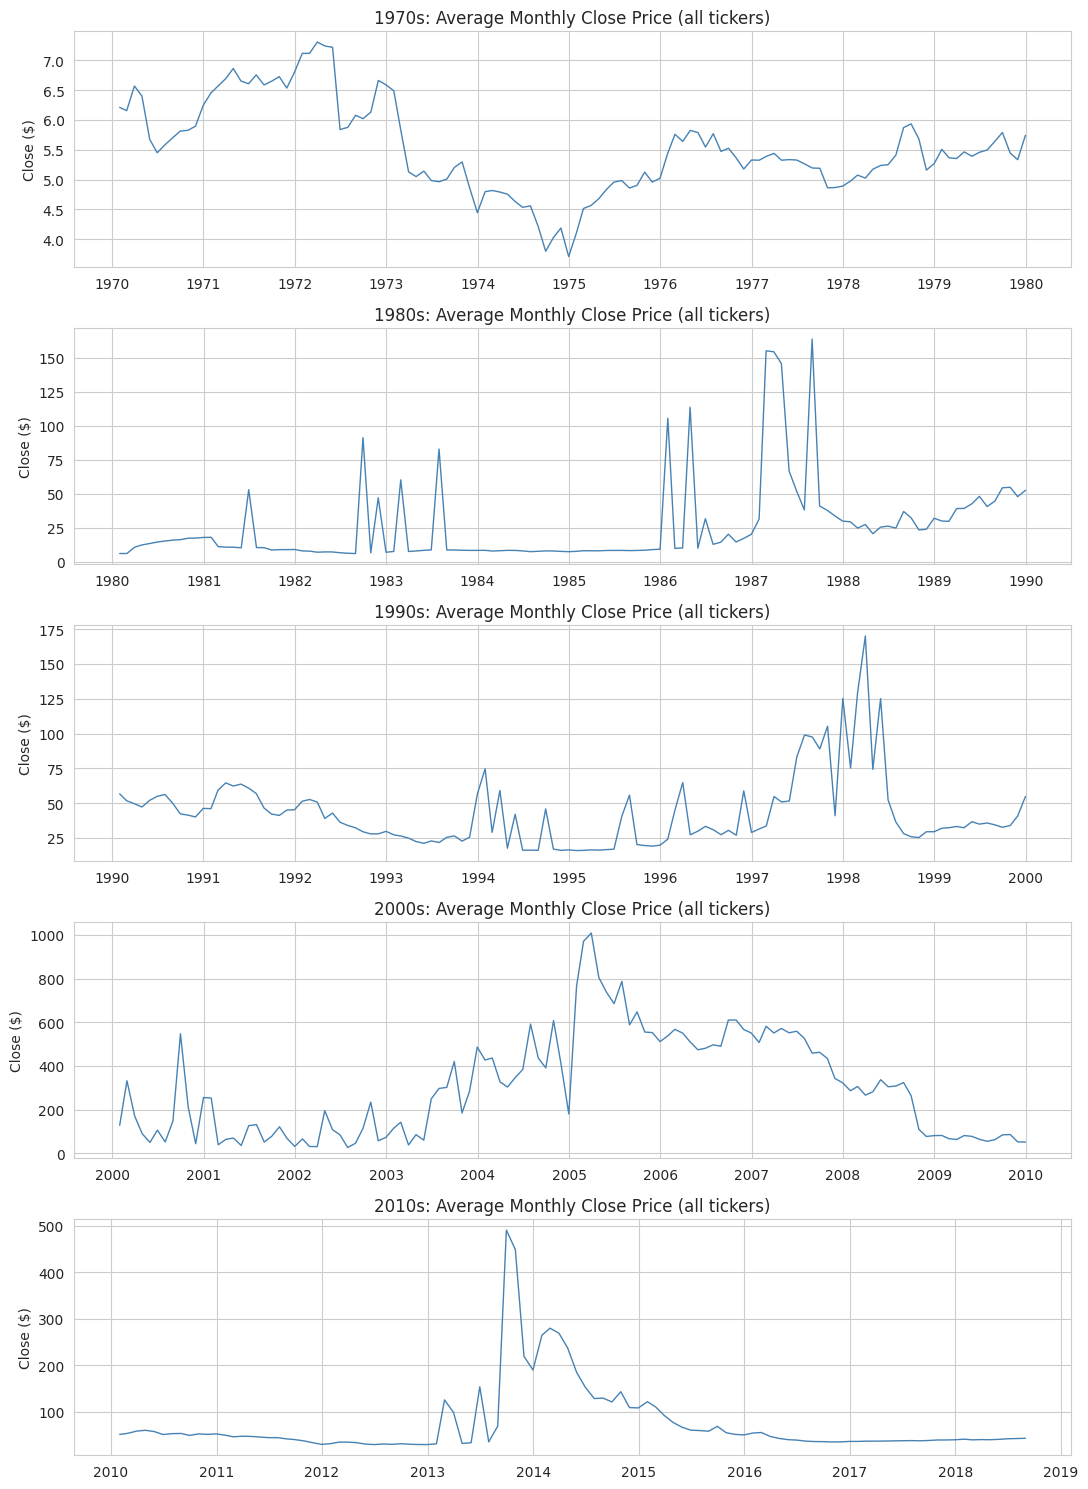

In [18]:
# Time series plots: average monthly close price, one subplot per decade
monthly_close = (
    prices_full.groupby(['decade', pd.Grouper(freq='ME')])['close']
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(len(decade_order), 1, figsize=(11, 3 * len(decade_order)), sharex=False)
for ax, d in zip(axes, decade_order):
    sub = monthly_close[monthly_close['decade'] == d]
    ax.plot(sub['date'], sub['close'], color='steelblue', linewidth=1)
    ax.set_title(f'{d}: Average Monthly Close Price (all tickers)')
    ax.set_ylabel('Close ($)')
plt.tight_layout()
plt.savefig('fig_monthly_close_by_decade.png', dpi=110)
plt.show()


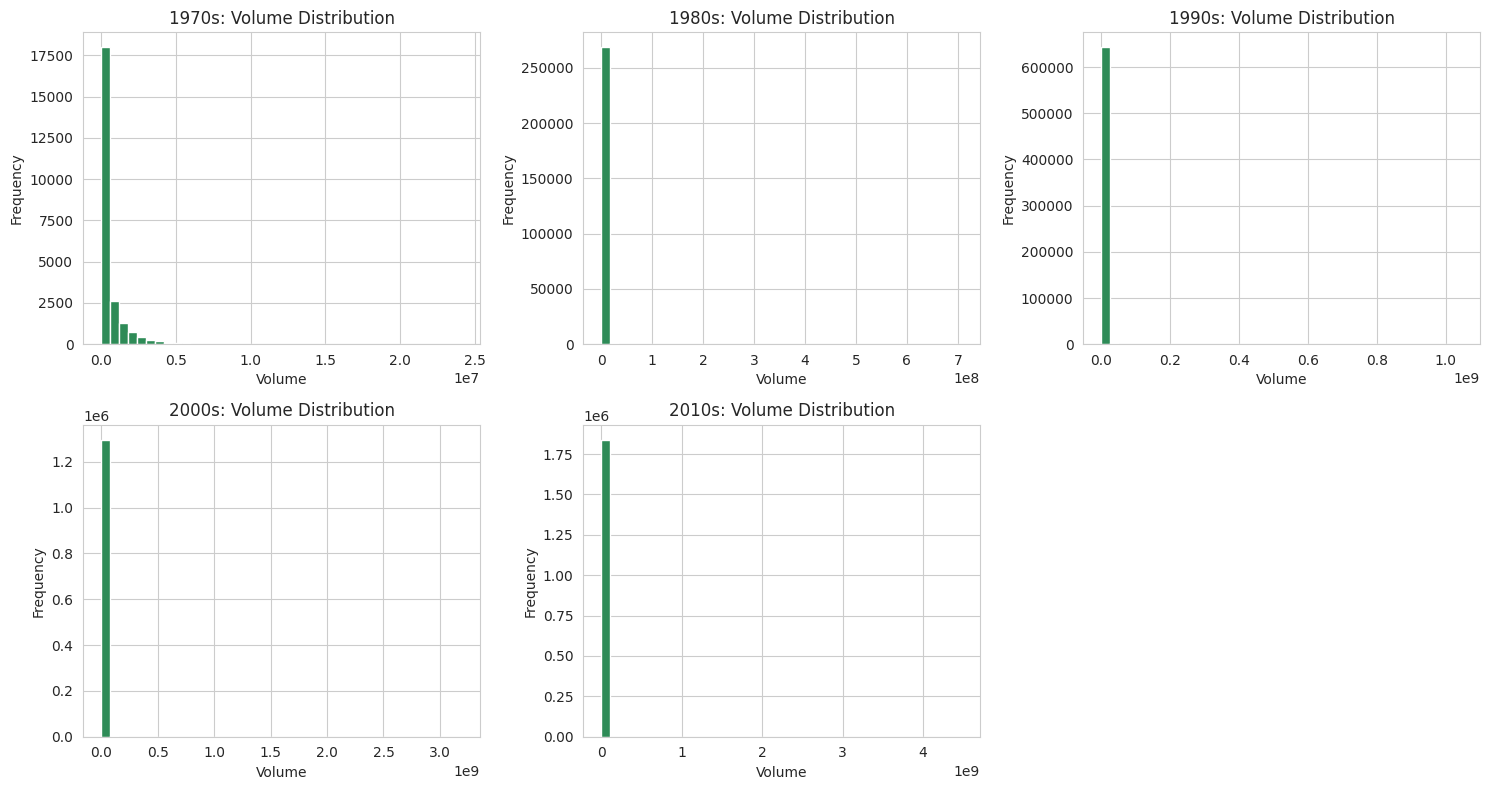

In [19]:
# Histograms for Volume by decade
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for ax, d in zip(axes, decade_order):
    df = prices_full[prices_full['decade'] == d]
    ax.hist(df['volume'], bins=40, color='seagreen', edgecolor='white')
    ax.set_title(f'{d}: Volume Distribution')
    ax.set_xlabel('Volume')
    ax.set_ylabel('Frequency')
for ax in axes[len(decade_order):]:
    ax.axis('off')
plt.tight_layout()
plt.savefig('fig_volume_hist_by_decade.png', dpi=110)
plt.show()


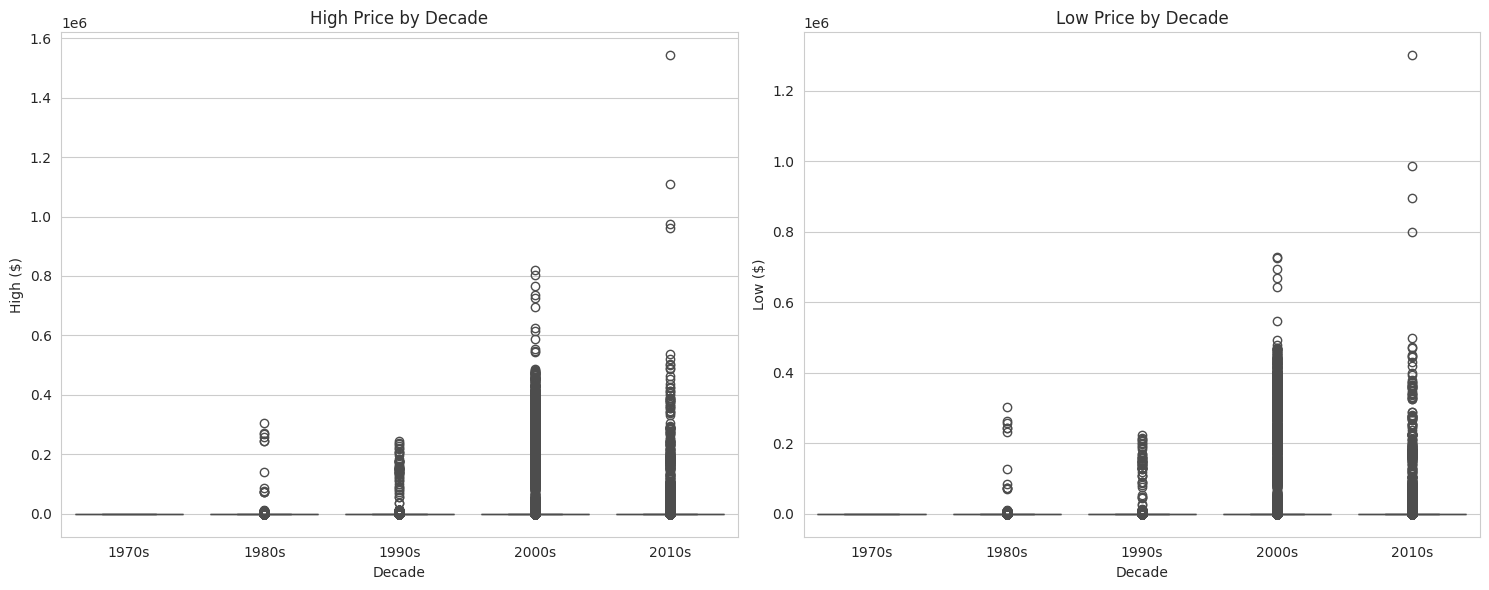

In [25]:
# Box plots for High and Low prices by decade
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=prices_full, x='decade', y='high', order=decade_order, ax=axes[0], color='red')
axes[0].set_title('High Price by Decade')
axes[0].set_xlabel('Decade'); axes[0].set_ylabel('High ($)')

sns.boxplot(data=prices_full, x='decade', y='low', order=decade_order, ax=axes[1], color='blue')
axes[1].set_title('Low Price by Decade')
axes[1].set_xlabel('Decade'); axes[1].set_ylabel('Low ($)')

plt.tight_layout()
plt.savefig('fig_high_low_boxplots.png', dpi=110)
plt.show()


## 5. Comparative Analysis

Compare summary statistics and visual patterns across decades.


In [22]:
# Percent change in key metrics decade over decade
volume_mean = combined.xs('volume', level='field')['mean'].loc[decade_order]
close_mean = combined.xs('close', level='field')['mean'].loc[decade_order]

metric_trend = pd.DataFrame({'volume_mean': volume_mean, 'close_mean': close_mean})
metric_trend['volume_pct_change'] = metric_trend['volume_mean'].pct_change() * 100
metric_trend['close_pct_change'] = metric_trend['close_mean'].pct_change() * 100
print(metric_trend.round(2))


        volume_mean  close_mean  volume_pct_change  close_pct_change
decade                                                              
1970s     548222.65        5.32                NaN               NaN
1980s     849262.41       29.42              54.91            453.24
1990s     915775.42       44.09               7.83             49.86
2000s    1970672.50      314.37             115.19            612.98
2010s    1992769.82       73.15               1.12            -76.73


In [23]:
# Volatility (std of close) trend across decades — a proxy for market turbulence
vol_trend = combined.xs('close', level='field')['std'].loc[decade_order]
print("Std. dev. of close price, by decade:")
print(vol_trend.round(2))


Std. dev. of close price, by decade:
decade
1970s       4.26
1980s    1330.26
1990s    1369.34
2000s    8771.22
2010s    2957.21
Name: std, dtype: float64


Cleaned Data Export


In [24]:
prices_full.reset_index().to_csv('cleaned_stock_data.csv', index=False)
print("Saved cleaned_stock_data.csv:", prices_full.shape)


Saved cleaned_stock_data.csv: (4084889, 12)
